# Logistic regression

## Imports

After the baseline, I decided to try two simple models: logistic regression and decision tree. I want to compare these two approaches and then, if necessary, move on to a more complex models.

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from heart_failure.dataset import split_data
from heart_failure.features import get_fe_pipeline
from heart_failure.modeling.models import build_lr_pipeline
from heart_failure.modeling.train import optuna_search, lr_space
from heart_failure.config.modeling import CV_SPLITS, OPTUNA_N_TRIALS, CV_SCORING, F_BETA_THRESHOLD, MIN_RECALL, \
    MODEL_STEP_NAME
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX, PROCESSED_DATA_DIR
from heart_failure.config.features import TEST_SIZE, RANDOM_STATE, VAL_SIZE
from heart_failure.reports import print_best_params
from heart_failure.modeling.evaluate import (
    get_metrics, log_metrics, optuna_cv_results_to_df, find_best_threshold
)
from heart_failure.modeling.predict import predict_by_threshold
from heart_failure.plots import plot_pr_curve

2026-06-25 14:23:14.571 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
MODEL_NAME = "logistic_regression"
mlflow.set_experiment(f"heart_failure")

<Experiment: artifact_location='file:D:/heart_failure/notebooks/mlruns/1', creation_time=1781534399229, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781534399229, lifecycle_stage='active', name='heart_failure', tags={}, trace_location=None, workspace='default'>

In [3]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")
rem_columns = pd.read_csv(PROCESSED_DATA_DIR / "remaining_cols.csv")
rem_columns = rem_columns.squeeze().to_list()

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

## Training

In [ ]:
fe_pipeline = get_fe_pipeline()
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_lr_pipeline,
    param_space=lr_space,
    n_trials=OPTUNA_N_TRIALS,
    n_splits=CV_SPLITS,
    scoring=CV_SCORING,
    random_state=RANDOM_STATE,
    fe_pipeline=fe_pipeline,
    rem_columns=rem_columns,
)

In [5]:
print_best_params(study)

Best parameters: {'model__solver': 'liblinear', 'model__C': 0.20019779028051599, 'model__max_iter': 190, 'model__tol': 7.144606722694915e-05, 'model__l1_ratio': 1}
Best score: 0.93471


In [6]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
27,"{'model__solver': 'liblinear', 'model__C': 0.2...",0.032504,0.934709,0.930019,0.874467,0.944922,0.965933,0.958206,1
26,"{'model__solver': 'liblinear', 'model__C': 0.1...",0.032937,0.934612,0.929952,0.873442,0.945394,0.965959,0.958312,2
28,"{'model__solver': 'lbfgs', 'model__C': 0.08455...",0.034046,0.934479,0.930635,0.871202,0.945267,0.968723,0.956565,3
40,"{'model__solver': 'lbfgs', 'model__C': 0.09527...",0.034077,0.934458,0.931197,0.870911,0.944968,0.968172,0.957044,4
31,"{'model__solver': 'liblinear', 'model__C': 0.1...",0.033966,0.934445,0.931227,0.871038,0.945015,0.967696,0.957251,5


The scores for different trials are very similar. Hyperparameters don't have that much of an impact on the results in this case. So, we're limited by the informativeness of the features.

In [7]:
lr = model.named_steps[MODEL_STEP_NAME]
weights = pd.Series(lr.coef_.ravel(), index=rem_columns)
weights.sort_values(key=abs, ascending=False)

remainder__Oldpeak_Cholesterol_ST_Slope_te    0.921821
target_encoder__ChestPainType                 0.682349
remainder__conjunctive_rules                  0.649837
binary_encoder__Sex                           0.517005
binary_encoder__FastingBS                     0.317297
binary_encoder__ExerciseAngina                0.251057
binarizer__Cholesterol                        0.176421
binarizer__MaxHR                             -0.134631
remainder__Oldpeak                            0.054109
binarizer__Age                                0.000000
dtype: float64

The model barely considers MaxHR. ST_Slope is perceived as the best feature, followed by conjunctive_rules. These two features are quite correlated (~0.75). What happens if we remove one of these features entirely?

### Threshold searching

In [8]:
y_val_proba = model.predict_proba(X_val)[:, 1]
best_threshold = find_best_threshold(y_val, y_val_proba, MIN_RECALL)
best_threshold

np.float64(0.10792188798662584)

## Metrics

In [9]:
print("Train metrics")
y_train_proba = model.predict_proba(X_train)[:, 1]
y_train_pred = predict_by_threshold(model, X_train)
train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
train_metrics

Train metrics


precision    0.877660
recall       0.926966
fpr          0.159170
pr_auc       0.942253
dtype: float64

In [13]:
print("Validate metrics")
y_val_pred = predict_by_threshold(model, X_val, best_threshold)
val_metrics = get_metrics(y_val, y_val_pred, y_val_proba)
val_metrics

Validate metrics


precision    0.716418
recall       0.979592
fpr          0.487179
pr_auc       0.932714
dtype: float64

Although we achieve the required recall (0.95), the precision is too poor. This makes the model, on the one hand, better than the baseline, but on the other, significantly worse (almost half of the true 0 cases are not recognized).

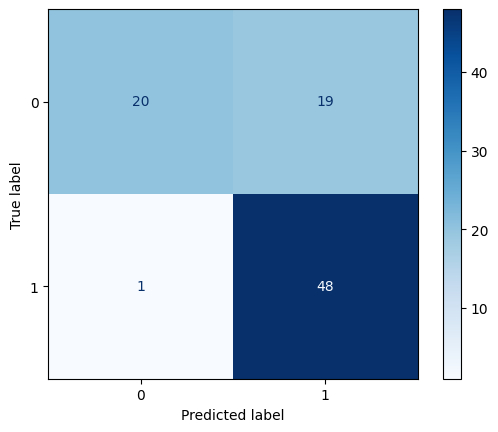

In [14]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues")
plt.show()

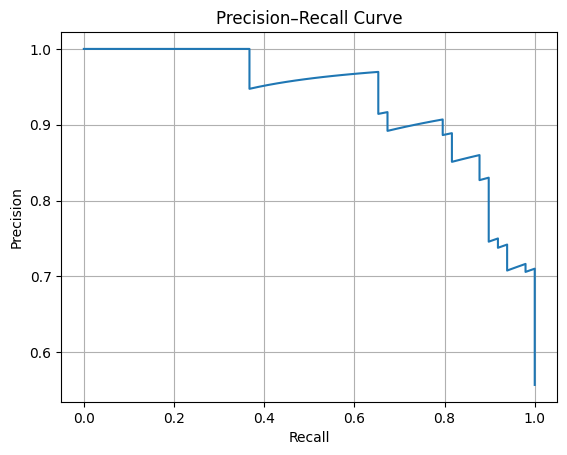

In [12]:
plot_pr_curve(y_val, y_val_proba)

In [15]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

Test metrics


precision    0.731884
recall       0.990196
fpr          0.451220
pr_auc       0.936881
dtype: float64

The model showed worse results than the baseline. I don't think logistic regression is appropriate in this case, so I want to try a decision tree.

In [16]:
with mlflow.start_run(run_name=MODEL_NAME) as run:
    mlflow.log_param("model", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("optuna_n_trials", OPTUNA_N_TRIALS)
    mlflow.log_param("remaining_columns", rem_columns)
    mlflow.log_param("f_beta_threshold", F_BETA_THRESHOLD)
    mlflow.log_param("proba_threshold", best_threshold)

    mlflow.sklearn.log_model(sk_model=model, name=MODEL_NAME)

    log_metrics(train_metrics, "train_")
    log_metrics(val_metrics, "val_")
    log_metrics(test_metrics, "test_")